In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv('/content/AirPassengers.csv')
df

In [ ]:
scaler = MinMaxScaler()
data = scaler.fit_transform(df['#Passengers'].values.reshape(-1,1))
data

In [5]:
# Crear secuencias para la serie temporal
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [6]:
seq_length = 12  # Usar 12 meses como ventana de entrada
X, y = create_sequences(data, seq_length)

In [7]:
from sklearn.model_selection import train_test_split

# Dividir en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Construcción del modelo LSTM en TensorFlow
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50, return_sequences=False),
    Dense(25, activation="relu"),
    Dense(1)
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:

# Entrenar el modelo
model.fit(X_train, y_train, epochs=100, verbose=1, validation_data=(X_test, y_test))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


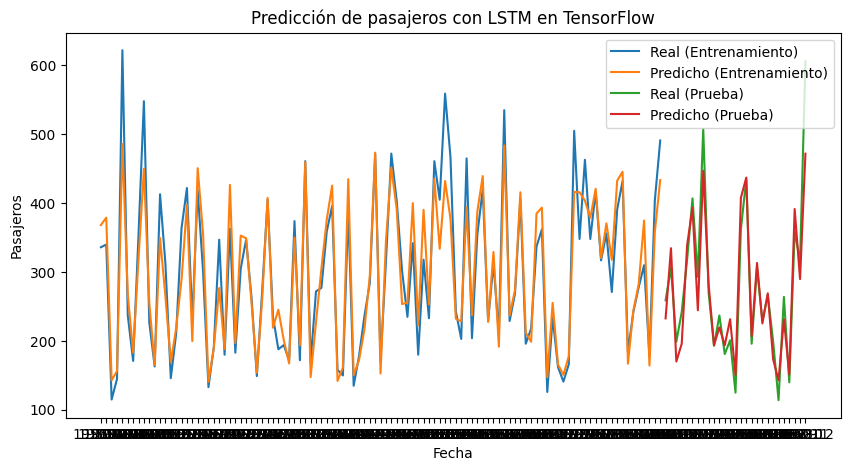

In [12]:
# Realizar predicciones
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
split = int(len(X) * 0.8)
# Graficar resultados
plt.figure(figsize=(10, 5))
plt.plot(df["Month"][seq_length:split+seq_length], scaler.inverse_transform(y_train), label="Real (Entrenamiento)")
plt.plot(df["Month"][seq_length:split+seq_length], scaler.inverse_transform(y_pred_train), label="Predicho (Entrenamiento)")
plt.plot(df["Month"][split+seq_length:], scaler.inverse_transform(y_test), label="Real (Prueba)")
plt.plot(df["Month"][split+seq_length:], scaler.inverse_transform(y_pred_test), label="Predicho (Prueba)")
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Pasajeros")
plt.title("Predicción de pasajeros con LSTM en TensorFlow")
plt.show()